In [1]:
!pip install -q xgboost shap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


Load dataset

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/aiplanethub/Datasets/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(df.shape)
print(df.columns.tolist())

(7043, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


Check target distribution

In [9]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [10]:
print(
    df["Churn"].value_counts(normalize=True) * 100
)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


Visualize churn distribution

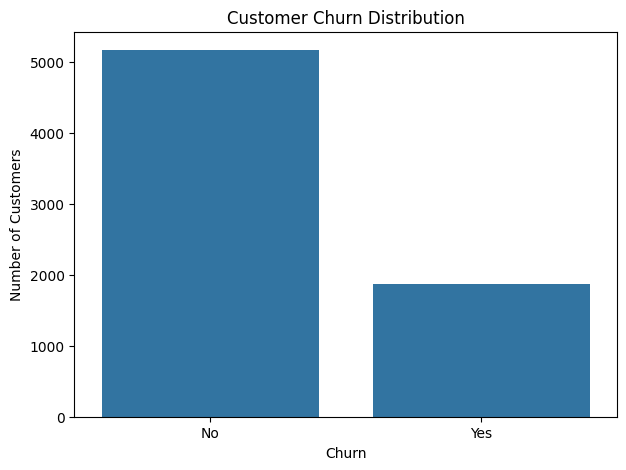

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

Data Cleaning

In [12]:
print(df["TotalCharges"].dtype)

object


In [13]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [14]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

Remove customer ID from ML features
customerID is an identifier, not a useful predictive feature.

In [16]:
customer_ids = df["customerID"].copy()

df = df.drop(columns=["customerID"])

print("customerID removed from model features.")

customerID removed from model features.


Encoding


In [17]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


Feature Engineering

In [18]:
df["avg_monthly_spend"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)
df[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "avg_monthly_spend"
]].head()

,tenure,MonthlyCharges,TotalCharges,avg_monthly_spend
0,1,29.85,29.85,29.850000
1,34,56.95,1889.50,55.573529
2,2,53.85,108.15,54.075000
3,45,42.30,1840.75,40.905556
4,2,70.70,151.65,75.825000


Create tenure groups

In [19]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 100],
    labels=[
        "0-6 months",
        "6-12 months",
        "12-24 months",
        "24-48 months",
        "48+ months"
    ]
)

df["tenure_group"].value_counts()

,count
tenure_group,
48+ months,2239
24-48 months,1594
0-6 months,1481
12-24 months,1024
6-12 months,705


Create service count

In [20]:
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["service_count"] = (
    df[service_columns]
    .apply(lambda row: sum(row == "Yes"), axis=1)
)

df[[
    "service_count",
    "Churn"
]].head()

,service_count,Churn
0,1,0
1,2,0
2,2,1
3,3,0
4,0,1


Create contract risk feature

In [21]:
df["month_to_month"] = (
    df["Contract"] == "Month-to-month"
).astype(int)

df[[
    "Contract",
    "month_to_month"
]].head()

,Contract,month_to_month
0,Month-to-month,1
1,One year,0
2,Month-to-month,1
3,One year,0
4,Month-to-month,1


Explore engineered features

In [22]:
df[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "avg_monthly_spend",
    "service_count",
    "month_to_month",
    "Churn"
]].describe()

,tenure,MonthlyCharges,TotalCharges,avg_monthly_spend,service_count,month_to_month,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,64.762906,2.037910,0.550192,0.265370
std,24.559481,30.090047,2266.794470,30.189796,1.847682,0.497510,0.441561
min,0.000000,18.250000,0.000000,13.775000,0.000000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,35.935156,0.000000,0.000000,0.000000
50%,29.000000,70.350000,1394.550000,70.337500,2.000000,1.000000,0.000000
75%,55.000000,89.850000,3786.600000,90.174158,3.000000,1.000000,1.000000
max,72.000000,118.750000,8684.800000,121.400000,6.000000,1.000000,1.000000


Prepare X and y

In [23]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 23)
y shape: (7043,)


Identify numerical and categorical columns

In [24]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'service_count', 'month_to_month']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


Train / Validation / Test Split

In [25]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (4930, 23)
Validation: (1056, 23)
Testing: (1057, 23)


In [26]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("scale_pos_weight:", round(scale_pos_weight, 3))

scale_pos_weight: 2.769


Create preprocessing pipeline

In [27]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


Create Logistic Regression pipeline

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


Create Random Forest pipeline

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_split=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


Create XGBoost pipeline

In [30]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("XGBoost pipeline created.")

XGBoost pipeline created.


Train Logistic Regression

In [31]:
print("Training Logistic Regression...")

logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression training complete.")

Training Logistic Regression...
Logistic Regression training complete.


Train Random Forest

In [32]:
print("Training Random Forest...")

rf_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest training complete.")

Training Random Forest...
Random Forest training complete.


Train XGBoost

In [33]:
print("Training XGBoost...")

xgb_pipeline.fit(
    X_train,
    y_train
)

print("XGBoost training complete.")

Training XGBoost...
XGBoost training complete.


Generate validation predictions

In [34]:
models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

validation_probabilities = {}

for name, model in models.items():
    validation_probabilities[name] = model.predict_proba(
        X_val
    )[:, 1]

print("Validation probabilities generated.")

Validation probabilities generated.


Generate validation class predictions

In [35]:
validation_predictions = {}

for name, probabilities in validation_probabilities.items():
    validation_predictions[name] = (
        probabilities >= 0.50
    ).astype(int)

print("Validation predictions generated.")

Validation predictions generated.


Evaluate the three models

In [36]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

results = []

for name in models:

    y_pred = validation_predictions[name]
    y_prob = validation_probabilities[name]

    results.append({
        "Model": name,
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_prob),
        "PR-AUC": average_precision_score(y_val, y_prob)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.508696,0.835714,0.632432,0.850016,0.651759
1,Random Forest,0.590909,0.603571,0.597173,0.831045,0.612084
2,XGBoost,0.536842,0.728571,0.618182,0.828413,0.614400


Sort models by F1

In [37]:
results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.508696,0.835714,0.632432,0.850016,0.651759
1,XGBoost,0.536842,0.728571,0.618182,0.828413,0.614400
2,Random Forest,0.590909,0.603571,0.597173,0.831045,0.612084


Confusion matrices

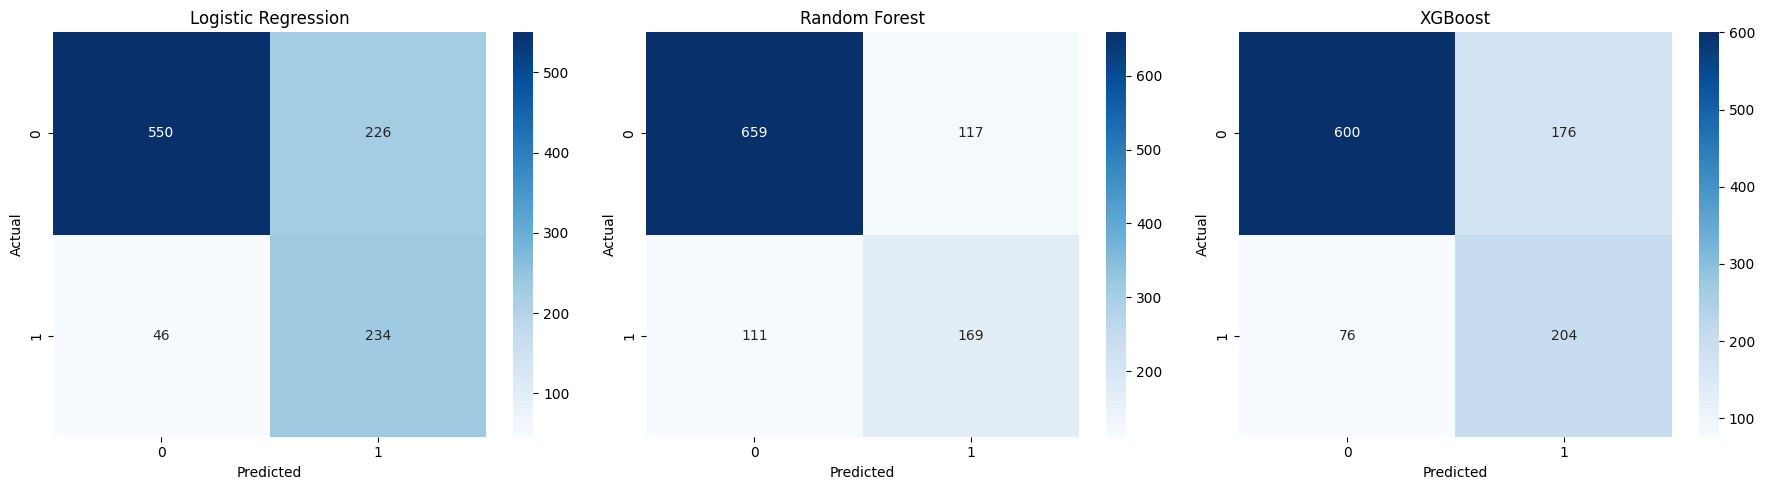

In [38]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, (name, predictions) in zip(
    axes,
    validation_predictions.items()
):

    cm = confusion_matrix(
        y_val,
        predictions
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

ROC curves

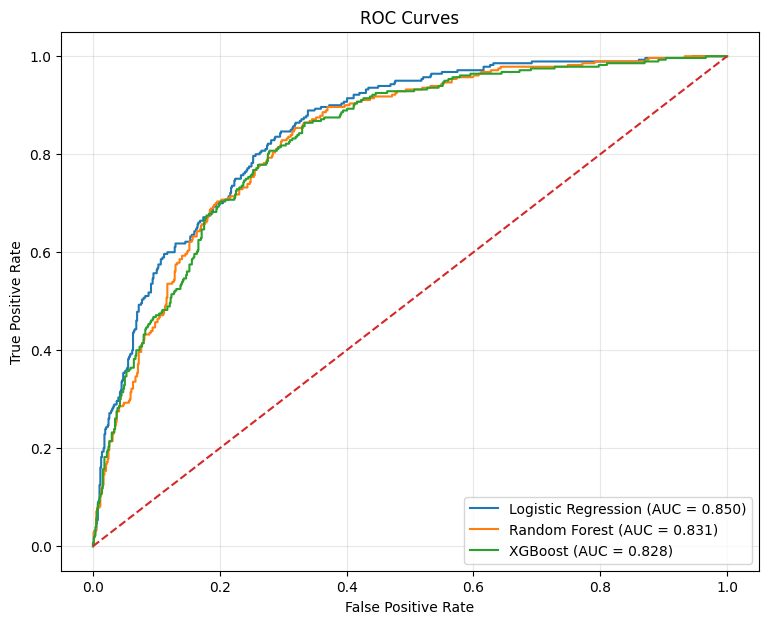

In [39]:
plt.figure(figsize=(9, 7))

for name, probabilities in validation_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_val,
        probabilities
    )

    auc = roc_auc_score(
        y_val,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Precision-Recall curves

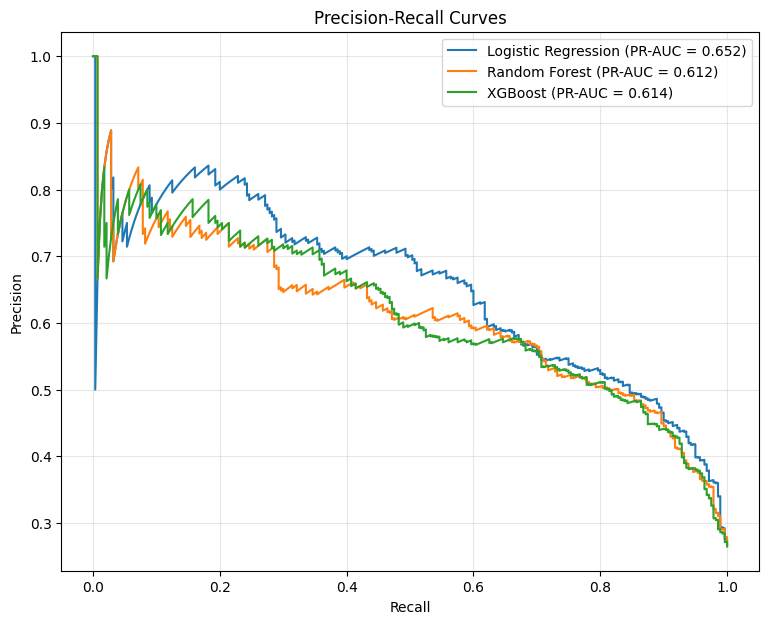

In [40]:
plt.figure(figsize=(9, 7))

for name, probabilities in validation_probabilities.items():

    precision, recall, _ = precision_recall_curve(
        y_val,
        probabilities
    )

    pr_auc = average_precision_score(
        y_val,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (PR-AUC = {pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Compare probability distributions

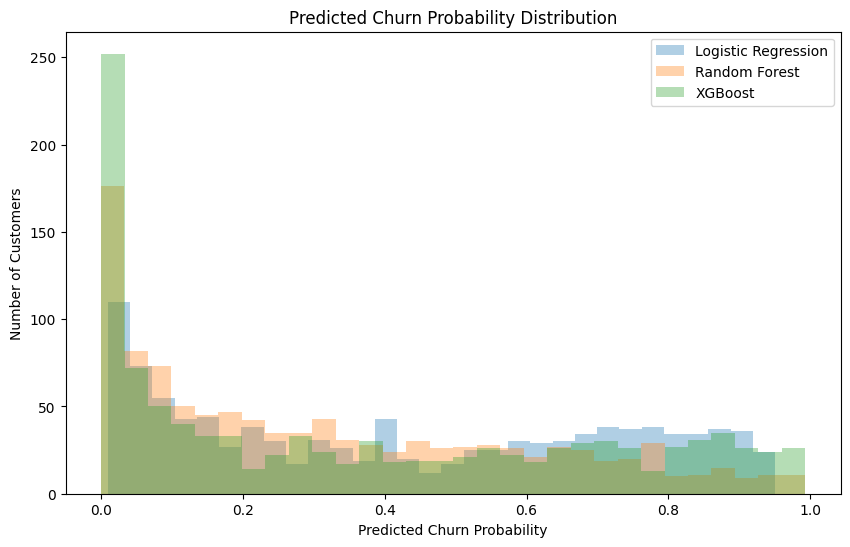

In [41]:
plt.figure(figsize=(10, 6))

for name, probabilities in validation_probabilities.items():

    plt.hist(
        probabilities,
        bins=30,
        alpha=0.35,
        label=name
    )

plt.xlabel("Predicted Churn Probability")
plt.ylabel("Number of Customers")
plt.title("Predicted Churn Probability Distribution")
plt.legend()

plt.show()

Threshold Optimization

In [42]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for name, probabilities in validation_probabilities.items():

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        threshold_results.append({
            "Model": name,
            "Threshold": threshold,
            "Precision": precision_score(
                y_val,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_val,
                predictions,
                zero_division=0
            ),
            "F1": f1_score(
                y_val,
                predictions,
                zero_division=0
            )
        })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.head()

,Model,Threshold,Precision,Recall,F1
0,Logistic Regression,0.10,0.336165,0.989286,0.501812
1,Logistic Regression,0.15,0.364362,0.978571,0.531008
2,Logistic Regression,0.20,0.386591,0.967857,0.552497
3,Logistic Regression,0.25,0.414330,0.950000,0.577007
4,Logistic Regression,0.30,0.428339,0.939286,0.588367


Find best F1 threshold for each model

In [43]:
best_thresholds = (
    threshold_df
    .sort_values("F1", ascending=False)
    .groupby("Model")
    .first()
    .reset_index()
)

best_thresholds

,Model,Threshold,Precision,Recall,F1
0,Logistic Regression,0.55,0.529691,0.796429,0.636234
1,Random Forest,0.30,0.495726,0.828571,0.620321
2,XGBoost,0.45,0.521951,0.764286,0.620290


Plot Precision vs Recall for XGBoost

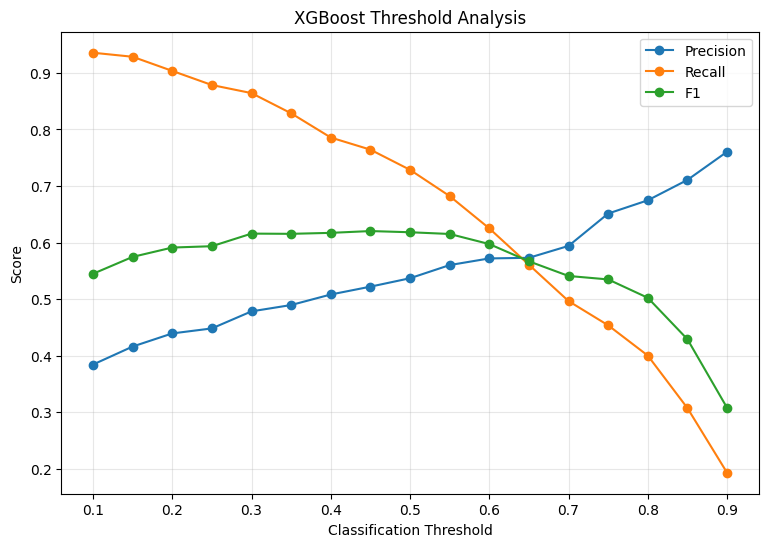

In [44]:
xgb_threshold_df = threshold_df[
    threshold_df["Model"] == "XGBoost"
]

plt.figure(figsize=(9, 6))

plt.plot(
    xgb_threshold_df["Threshold"],
    xgb_threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    xgb_threshold_df["Threshold"],
    xgb_threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    xgb_threshold_df["Threshold"],
    xgb_threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("XGBoost Threshold Analysis")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Import calibration tools

In [45]:
from sklearn.calibration import (
    calibration_curve,
    CalibratedClassifierCV
)

from sklearn.metrics import brier_score_loss

Calibration curves

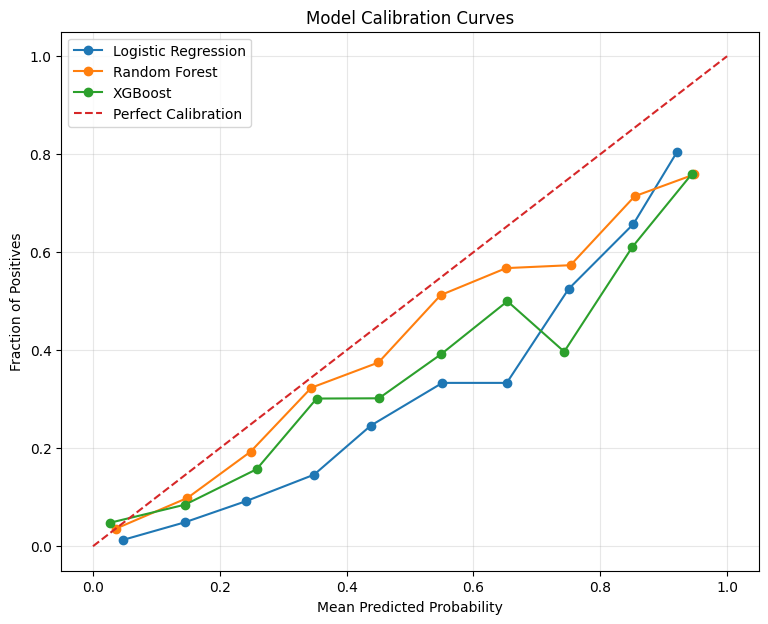

In [46]:
plt.figure(figsize=(9, 7))

for name, probabilities in validation_probabilities.items():

    fraction_of_positives, mean_predicted_value = (
        calibration_curve(
            y_val,
            probabilities,
            n_bins=10,
            strategy="uniform"
        )
    )

    plt.plot(
        mean_predicted_value,
        fraction_of_positives,
        marker="o",
        label=name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Model Calibration Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Calculate Brier score

In [47]:
brier_results = []

for name, probabilities in validation_probabilities.items():

    score = brier_score_loss(
        y_val,
        probabilities
    )

    brier_results.append({
        "Model": name,
        "Brier Score": score
    })

brier_df = pd.DataFrame(brier_results)

brier_df.sort_values(
    "Brier Score"
)

,Model,Brier Score
1,Random Forest,0.146158
2,XGBoost,0.161113
0,Logistic Regression,0.166938


**Why XGBoost is carried forward as the final model**

At the default 0.50 threshold, Logistic Regression actually has the best F1
and ROC-AUC on validation, and after threshold tuning all three models are
close. XGBoost is chosen here specifically because it has the **lowest
Brier score** (best-calibrated raw probabilities) of the three models — and
since the end product is a per-customer churn *probability* / risk score
(see the Risk Level section below), calibration quality matters more than
squeezing out a slightly higher F1 at a single fixed threshold. If the
end product were a hard yes/no churn flag instead, Logistic Regression
would be a reasonable — and more interpretable — alternative.

Calibrate the Models

In [48]:
calibrated_xgb = CalibratedClassifierCV(
    xgb_pipeline,
    method="isotonic",
    cv=5
)

calibrated_xgb.fit(
    X_train,
    y_train
)

print("Calibrated XGBoost trained successfully.")

Calibrated XGBoost trained successfully.


Generate calibrated probabilities

In [49]:
calibrated_xgb_prob = calibrated_xgb.predict_proba(
    X_val
)[:, 1]

print(calibrated_xgb_prob[:10])

[0.00805307 0.35898997 0.05972572 0.01569487 0.975      0.84255573
 0.44533435 0.18459328 0.40815874 0.11973277]


Re-optimize the decision threshold on calibrated probabilities

In [51]:
calibrated_threshold_results = []

for threshold in thresholds:

    predictions = (
        calibrated_xgb_prob >= threshold
    ).astype(int)

    calibrated_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, predictions, zero_division=0),
        "Recall": recall_score(y_val, predictions, zero_division=0),
        "F1": f1_score(y_val, predictions, zero_division=0)
    })

calibrated_threshold_df = pd.DataFrame(calibrated_threshold_results)

best_calibrated_threshold = (
    calibrated_threshold_df
    .sort_values("F1", ascending=False)
    .iloc[0]["Threshold"]
)

print("Best threshold for calibrated XGBoost:", best_calibrated_threshold)

calibrated_threshold_df.sort_values("F1", ascending=False).head()

Best threshold for calibrated XGBoost: 0.25000000000000006


,Threshold,Precision,Recall,F1
3,0.25,0.496894,0.857143,0.629096
4,0.30,0.528678,0.757143,0.622614
5,0.35,0.561194,0.671429,0.611382
2,0.20,0.457721,0.889286,0.604369
6,0.40,0.581315,0.600000,0.590510


Evaluate Calibrated XGBoost

In [52]:
calibrated_xgb_pred = (
    calibrated_xgb_prob >= best_calibrated_threshold
).astype(int)

calibrated_metrics = {
    "Precision": precision_score(
        y_val,
        calibrated_xgb_pred
    ),
    "Recall": recall_score(
        y_val,
        calibrated_xgb_pred
    ),
    "F1": f1_score(
        y_val,
        calibrated_xgb_pred
    ),
    "ROC-AUC": roc_auc_score(
        y_val,
        calibrated_xgb_prob
    ),
    "PR-AUC": average_precision_score(
        y_val,
        calibrated_xgb_prob
    ),
    "Brier Score": brier_score_loss(
        y_val,
        calibrated_xgb_prob
    )
}

pd.DataFrame(
    [calibrated_metrics],
    index=[f"Calibrated XGBoost (threshold={best_calibrated_threshold:.2f})"]
)

,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier Score
Calibrated XGBoost (threshold=0.25),0.496894,0.857143,0.629096,0.833224,0.611148,0.141885


Final Test Evaluation

In [53]:
test_probabilities = calibrated_xgb.predict_proba(
    X_test
)[:, 1]

test_predictions = (
    test_probabilities >= best_calibrated_threshold
).astype(int)

Final metrics

In [54]:
final_results = {
    "Precision": precision_score(
        y_test,
        test_predictions
    ),
    "Recall": recall_score(
        y_test,
        test_predictions
    ),
    "F1": f1_score(
        y_test,
        test_predictions
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        test_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_test,
        test_probabilities
    ),
    "Brier Score": brier_score_loss(
        y_test,
        test_probabilities
    )
}

final_results_df = pd.DataFrame(
    [final_results],
    index=[f"Calibrated XGBoost (threshold={best_calibrated_threshold:.2f})"]
)

final_results_df

,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier Score
Calibrated XGBoost (threshold=0.25),0.508969,0.807829,0.624484,0.825662,0.641148,0.141821


Final Confusion Matrix

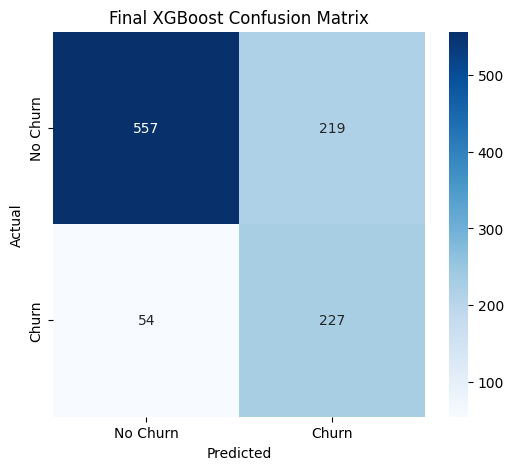

In [55]:
cm = confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final XGBoost Confusion Matrix")

plt.show()

Classification Report

In [56]:
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80       776
       Churn       0.51      0.81      0.62       281

    accuracy                           0.74      1057
   macro avg       0.71      0.76      0.71      1057
weighted avg       0.80      0.74      0.76      1057



Individual Customer Prediction

In [57]:
customer_index = X_test.index[0]

customer = X_test.loc[[customer_index]]

actual_churn = y_test.loc[customer_index]

customer_probability = calibrated_xgb.predict_proba(
    customer
)[0, 1]

print("Customer index:", customer_index)
print("Actual churn:", actual_churn)
print("Predicted churn probability:", round(customer_probability, 4))

Customer index: 1639
Actual churn: 1
Predicted churn probability: 0.4196


Risk Level

In [58]:
def get_risk_level(probability):

    if probability >= 0.75:
        return "HIGH"

    elif probability >= 0.40:
        return "MEDIUM"

    else:
        return "LOW"


risk_level = get_risk_level(
    customer_probability
)

print("Risk Level:", risk_level)

Risk Level: MEDIUM


SHAP Explainability

In [59]:
xgb_model = xgb_pipeline.named_steps["model"]

preprocessor_fitted = (
    xgb_pipeline.named_steps["preprocessor"]
)

print("XGBoost model extracted.")

XGBoost model extracted.


In [60]:
X_train_transformed = preprocessor_fitted.transform(
    X_train
)

X_test_transformed = preprocessor_fitted.transform(
    X_test
)

print(
    "Transformed training shape:",
    X_train_transformed.shape
)

print(
    "Transformed test shape:",
    X_test_transformed.shape
)

Transformed training shape: (4930, 53)
Transformed test shape: (1057, 53)


In [61]:
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

print("Number of features:", len(feature_names))

feature_names[:20]

Number of features: 53


array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'num__avg_monthly_spend',
       'num__service_count', 'num__month_to_month', 'cat__gender_Female',
       'cat__gender_Male', 'cat__Partner_No', 'cat__Partner_Yes',
       'cat__Dependents_No', 'cat__Dependents_Yes',
       'cat__PhoneService_No', 'cat__PhoneService_Yes',
       'cat__MultipleLines_No', 'cat__MultipleLines_No phone service',
       'cat__MultipleLines_Yes', 'cat__InternetService_DSL',
       'cat__InternetService_Fiber optic'], dtype=object)

In [62]:
import shap

explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(
    X_test_transformed
)

print("SHAP values calculated.")

SHAP values calculated.


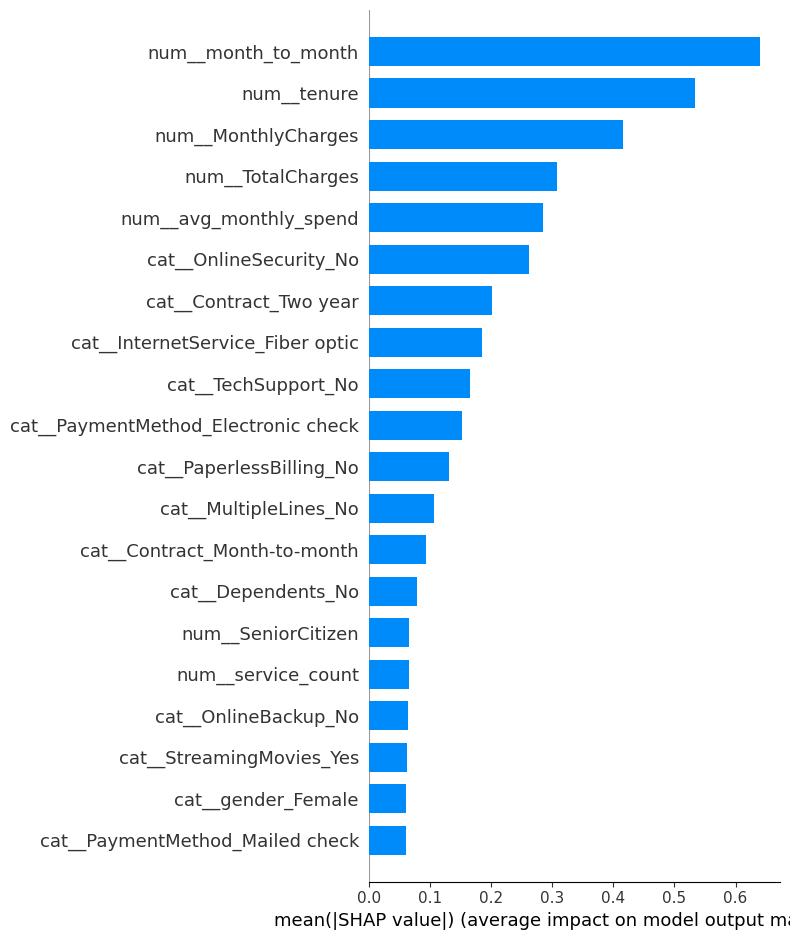

In [63]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

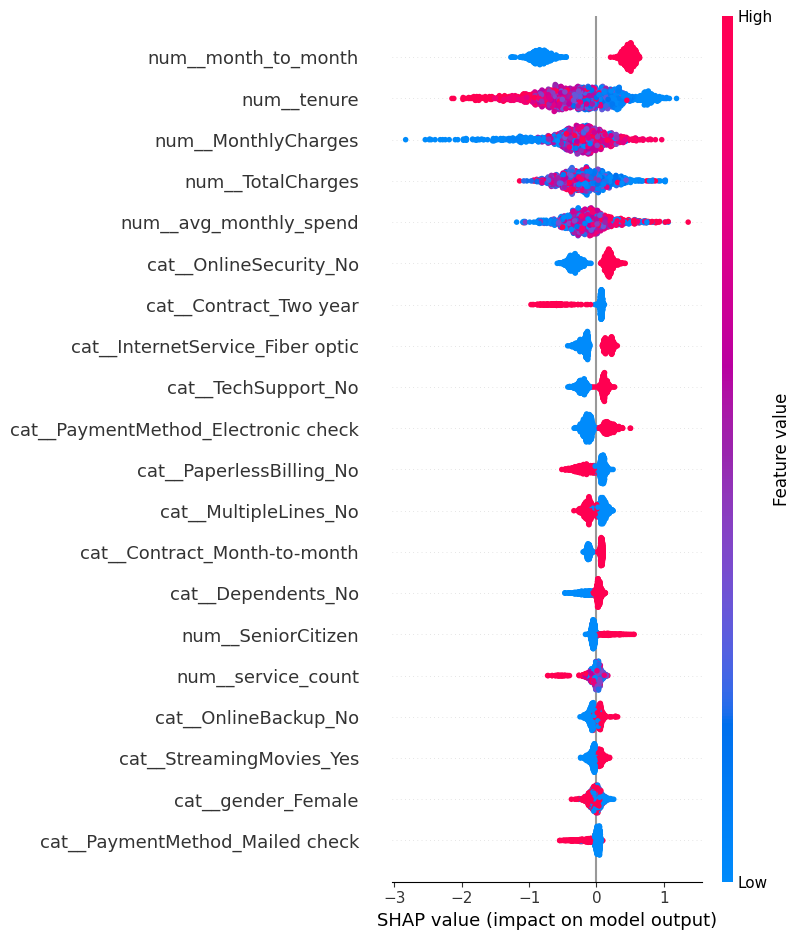

In [64]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

Explain One Customer

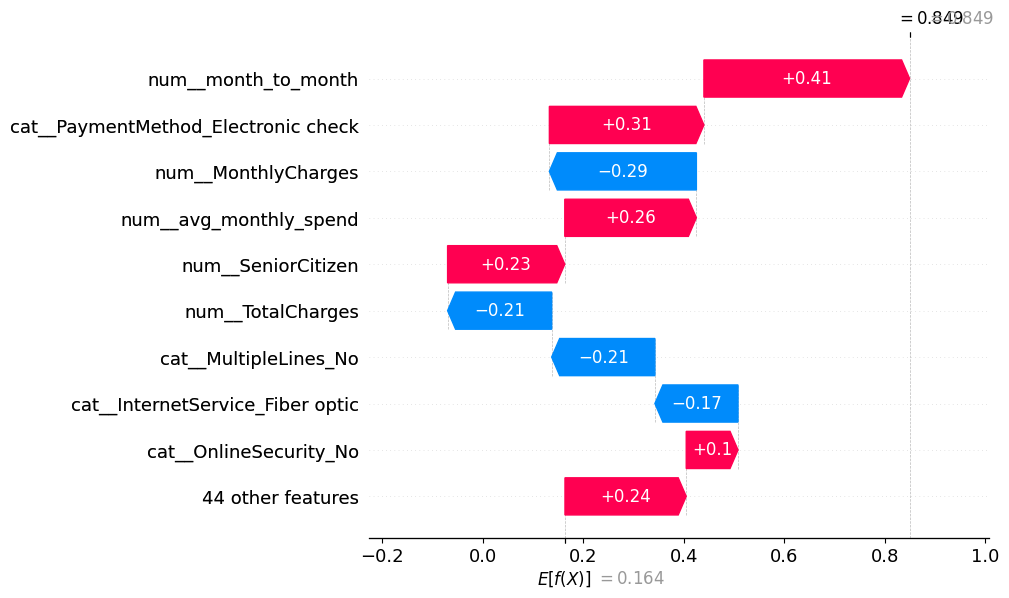

In [65]:
customer_position = list(
    X_test.index
).index(customer_index)

customer_shap_values = shap_values[
    customer_position
]

customer_feature_values = X_test_transformed[
    customer_position
]

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    customer_shap_values,
    feature_names=feature_names,
    max_display=10
)